<a href="https://colab.research.google.com/github/Samplergithub769/mtu-xsens-imu-Sensor/blob/main/mtu_xsens_imu_Sensor%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt00

**Load Datasets**

In [2]:
df_25hz=pd.read_csv("25hz.csv",skiprows=12)
df_50hz=pd.read_csv("50hz.csv",skiprows=12)
df_100hz=pd.read_csv("100hz.csv",skiprows=12)

df_noise_25hz=pd.read_csv("Noise_25HZ.csv",skiprows=12)
df_noise_50hz=pd.read_csv("Noise_50hz.csv",skiprows=12)
df_noise_100hz=pd.read_csv("Noise_100hz.csv",skiprows=12)

**Display the first few rows and information for each DataFrame**

In [3]:
print("25hz.csv:")
print(df_25hz.head())

print("\n50hz.csv:")
print(df_50hz.head())

print("\n100hz.csv:")
print(df_100hz.head())

print("\nNoise_25HZ.csv:")
print(df_noise_25hz.head())

print("\nNoise_50hz.csv:")
print(df_noise_50hz.head())

print("\nNoise_100hz.csv:")
print(df_noise_100hz.head())

25hz.csv:
   PacketCounter  SampleTimeFine  Acc_X  Acc_Y  Acc_Z   AccHR_X   AccHR_Y  \
0          57364        38214066    0.0    0.0    0.0 -0.004889  0.327786   
1          57366        38214106    0.0    0.0    0.0 -0.043509  0.356337   
2          57368        38214145    0.0    0.0    0.0 -0.029078  0.342039   
3          57369        38214165    0.0    0.0    0.0 -0.000167  0.342172   
4          57371        38214205    0.0    0.0    0.0  0.019263  0.313533   

    AccHR_Z  Mag_X  Mag_Y  Mag_Z  Roll  Pitch  Yaw  Temperature  
0  9.762954    0.0    0.0    0.0   0.0    0.0  0.0          0.0  
1  9.739222    0.0    0.0    0.0   0.0    0.0  0.0          0.0  
2  9.739135    0.0    0.0    0.0   0.0    0.0  0.0          0.0  
3  9.762895    0.0    0.0    0.0   0.0    0.0  0.0          0.0  
4  9.781975    0.0    0.0    0.0   0.0    0.0  0.0          0.0  

50hz.csv:
   PacketCounter  SampleTimeFine     Acc_X     Acc_Y     Acc_Z   AccHR_X  \
0          36606         7038992 -0.101958  

In [4]:
print("Info for df_25hz:")
df_25hz.info()
print("\nMissing values in df_25hz:")
print(df_25hz.isnull().sum())

print("\nInfo for df_50hz:")
df_50hz.info()
print("\nMissing values in df_50hz:")
print(df_50hz.isnull().sum())

print("\nInfo for df_100hz:")
df_100hz.info()
print("\nMissing values in df_100hz:")
print(df_100hz.isnull().sum())

print("\nInfo for df_noise_25hz:")
df_noise_25hz.info()
print("\nMissing values in df_noise_25hz:")
print(df_noise_25hz.isnull().sum())

print("\nInfo for df_noise_50hz:")
df_noise_50hz.info()
print("\nMissing values in df_noise_50hz:")
print(df_noise_50hz.isnull().sum())

print("\nInfo for df_noise_100hz:")
df_noise_100hz.info()
print("\nMissing values in df_noise_100hz:")
print(df_noise_100hz.isnull().sum())


Info for df_25hz:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530000 entries, 0 to 529999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PacketCounter   530000 non-null  int64  
 1   SampleTimeFine  530000 non-null  int64  
 2   Acc_X           530000 non-null  float64
 3   Acc_Y           530000 non-null  float64
 4   Acc_Z           530000 non-null  float64
 5   AccHR_X         530000 non-null  float64
 6   AccHR_Y         530000 non-null  float64
 7   AccHR_Z         530000 non-null  float64
 8   Mag_X           530000 non-null  float64
 9   Mag_Y           530000 non-null  float64
 10  Mag_Z           530000 non-null  float64
 11  Roll            530000 non-null  float64
 12  Pitch           530000 non-null  float64
 13  Yaw             530000 non-null  float64
 14  Temperature     530000 non-null  float64
dtypes: float64(13), int64(2)
memory usage: 60.7 MB

Missing values in df_25hz:
PacketCou

**Project Objective**

Predict surrounding temperature and magnetic field values that are influenced by device behavior (movement, frequency, noise, etc.)

In [5]:
# Combine clean and noisy data with labels and frequency information

df_25hz['label']=0
df_25hz['Freq']=25

df_noise_25hz['label']=1
df_noise_25hz['Freq']=25

df_50hz['label']=0
df_50hz['Freq']=50

df_noise_50hz['label']=1
df_noise_50hz['Freq']=50

df_100hz['label']=0
df_100hz['Freq']=100

df_noise_100hz['label']=1
df_noise_100hz['Freq']=100

# Combine all dataframes
combined_df=pd.concat([
    df_25hz,df_noise_25hz,
    df_50hz,df_noise_50hz,
    df_100hz,df_noise_100hz
],ignore_index=True)

# Display the rows of the combined dataframe
display(combined_df)

#Display info and missing values for the combined dataframe
print("\nInfo for combined_df")
combined_df.info()

print("\nMissing values in combined_df:")
print(combined_df.isnull().sum())



,PacketCounter,SampleTimeFine,Acc_X,Acc_Y,Acc_Z,AccHR_X,AccHR_Y,AccHR_Z,Mag_X,Mag_Y,Mag_Z,Roll,Pitch,Yaw,Temperature,label,Freq
0,57364,38214066,0.0,0.0,0.0,-0.004889,0.327786,9.762954,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,25
1,57366,38214106,0.0,0.0,0.0,-0.043509,0.356337,9.739222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,25
2,57368,38214145,0.0,0.0,0.0,-0.029078,0.342039,9.739135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,25
3,57369,38214165,0.0,0.0,0.0,-0.000167,0.342172,9.762895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,25
4,57371,38214205,0.0,0.0,0.0,0.019263,0.313533,9.781975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563552,64667,22709038,0.0,0.0,0.0,0.091821,0.209589,9.732641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,100
1563553,64672,22709078,0.0,0.0,0.0,0.082333,0.214332,9.747093,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,100
1563554,64676,22709118,0.0,0.0,0.0,0.115760,0.233636,9.746809,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,100
1563555,64681,22709157,0.0,0.0,0.0,0.096630,0.228760,9.746962,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,100



Info for combined_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563557 entries, 0 to 1563556
Data columns (total 17 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   PacketCounter   1563557 non-null  int64  
 1   SampleTimeFine  1563557 non-null  int64  
 2   Acc_X           1563557 non-null  float64
 3   Acc_Y           1563557 non-null  float64
 4   Acc_Z           1563557 non-null  float64
 5   AccHR_X         1563557 non-null  float64
 6   AccHR_Y         1563557 non-null  float64
 7   AccHR_Z         1563557 non-null  float64
 8   Mag_X           1563557 non-null  float64
 9   Mag_Y           1563557 non-null  float64
 10  Mag_Z           1563557 non-null  float64
 11  Roll            1563557 non-null  float64
 12  Pitch           1563557 non-null  float64
 13  Yaw             1563557 non-null  float64
 14  Temperature     1563557 non-null  float64
 15  label           1563557 non-null  int64  
 16  Freq          


Define the features (X) and the target variables (y) for the model

In [6]:
features = ['SampleTimeFine', 'Acc_X', 'Acc_Y', 'Acc_Z', 'AccHR_X', 'AccHR_Y', 'AccHR_Z', 'Roll', 'Pitch', 'Yaw', 'Freq', 'label']
targets = ['Temperature', 'Mag_X', 'Mag_Y', 'Mag_Z']

X = combined_df[features]
y = combined_df[targets]


Split the combined dataset into training and testing sets.


In [7]:
pip install scikit-learn

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Import RandomForestRegressor model and train it on the training data**



In [9]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)


Calculate evaluation metrics (MSE, RMSE, MAE, R-squared) for the model's predictions on the test set.


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred=model.predict(X_test)

for i, target in enumerate(targets):
  mse=mean_squared_error(y_test[target],y_pred[:,i])
  rmse=np.sqrt(mse)
  mae=mean_absolute_error(y_test[target],y_pred[:,i])
  r2=r2_score(y_test[target],y_pred[:,i])


  print(f"Metrics for {target}:")
  print(f"Mean Squared Error (MSE):{mse:.4f}")
  print(f"Root Mean Squared Error (RMSE):{rmse:.4f}")
  print(f"Mean Absolute Error (MAE):{mae:.4f}")
  print(f"R-squared (R2):{r2:.4f}")
  print("-" * 30)



Metrics for Temperature:
Mean Squared Error (MSE):0.0001
Root Mean Squared Error (RMSE):0.0077
Mean Absolute Error (MAE):0.0002
R-squared (R2):1.0000
------------------------------
Metrics for Mag_X:
Mean Squared Error (MSE):0.0002
Root Mean Squared Error (RMSE):0.0130
Mean Absolute Error (MAE):0.0002
R-squared (R2):0.9891
------------------------------
Metrics for Mag_Y:
Mean Squared Error (MSE):0.0005
Root Mean Squared Error (RMSE):0.0215
Mean Absolute Error (MAE):0.0002
R-squared (R2):0.9312
------------------------------
Metrics for Mag_Z:
Mean Squared Error (MSE):0.0002
Root Mean Squared Error (RMSE):0.0153
Mean Absolute Error (MAE):0.0002
R-squared (R2):0.9809
------------------------------


Plot the actual vs. predicted values for temperature and magnetic field to visualize the model's performance.


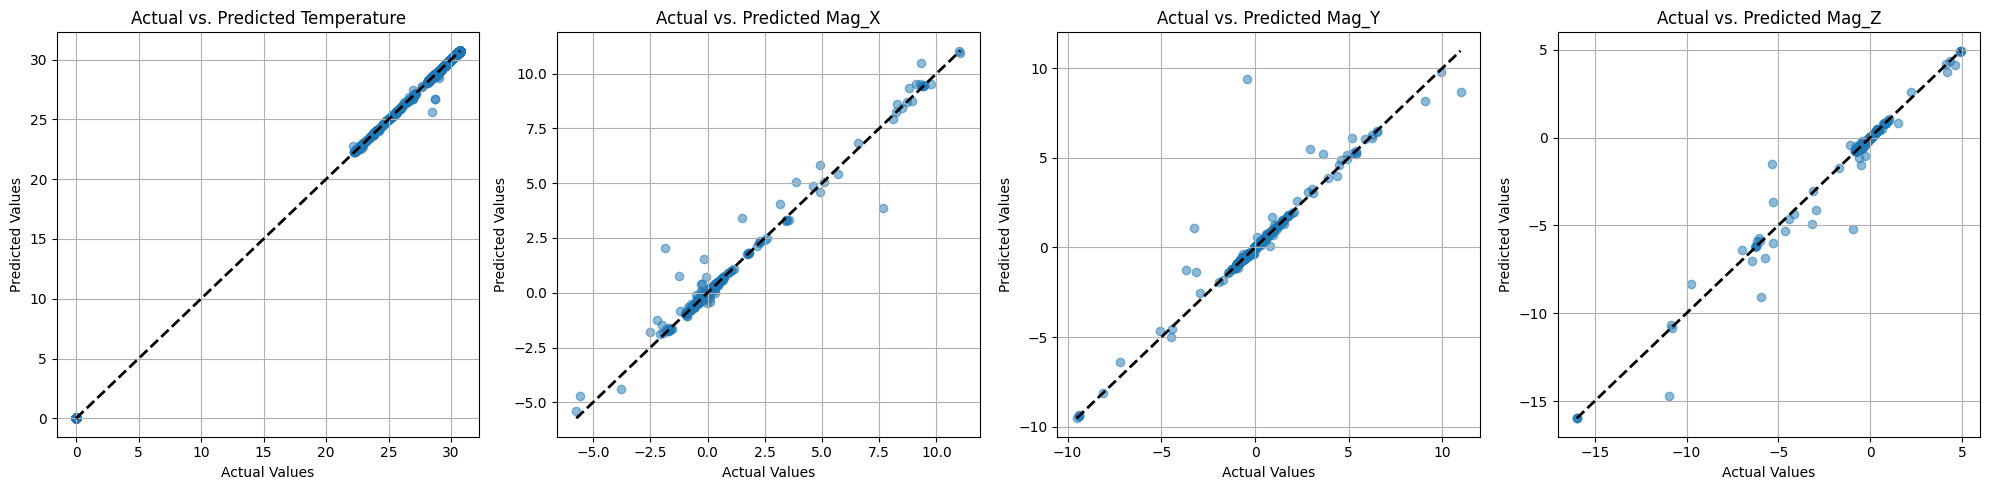

In [11]:
fig,axes=plt.subplots(1,4,figsize=(20,5))
targets=['Temperature','Mag_X','Mag_Y','Mag_Z']

for i, target in enumerate(targets):
  axes[i].scatter(y_test[target],y_pred[:,i],alpha=0.5)
  axes[i].plot([y_test[target].min(),y_test[target].max()],[y_test[target].min(),y_test[target].max()],'k--',lw=2)
  axes[i].set_title(f'Actual vs. Predicted {target}')
  axes[i].set_xlabel('Actual Values')
  axes[i].set_ylabel('Predicted Values')
  axes[i].grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Create a DataFrame for actual and predicted values
temperature_magnetometer_results = pd.DataFrame({
    'Actual_Temperature': y_test['Temperature'],
    'Predicted_Temperature_RFR': y_pred[:, 0].round(2),
    'Actual_Mag_X': y_test['Mag_X'],
    'Predicted_Mag_X_RFR': y_pred[:, 1].round(6),
    'Actual_Mag_Y': y_test['Mag_Y'],
    'Predicted_Mag_Y_RFR': y_pred[:, 2].round(6),
    'Actual_Mag_Z': y_test['Mag_Z'],
    'Predicted_Mag_Z_RFR': y_pred[:, 3].round(6)
})



In [13]:
non_zero_rows = temperature_magnetometer_results[
    (temperature_magnetometer_results != 0).any(axis=1)
]

non_zero_rows=non_zero_rows.reset_index(drop=True)
non_zero_rows

,Actual_Temperature,Predicted_Temperature_RFR,Actual_Mag_X,Predicted_Mag_X_RFR,Actual_Mag_Y,Predicted_Mag_Y_RFR,Actual_Mag_Z,Predicted_Mag_Z_RFR
0,28.65,28.64,-0.125710,-0.085239,-0.680445,-0.729061,-0.568368,-0.540539
1,29.18,29.18,0.383101,0.383651,-0.603166,-0.601957,-0.527010,-0.526641
2,30.42,30.42,-0.704707,-0.704976,0.042619,0.041673,-0.489074,-0.491020
3,29.21,29.21,0.398763,0.399853,-0.617861,-0.618725,-0.544572,-0.544537
4,28.64,28.64,-0.072370,-0.072726,-0.723065,-0.724349,-0.532325,-0.531811
...,...,...,...,...,...,...,...,...
7265,30.72,30.71,-0.707646,-0.707349,0.037128,0.037624,-0.489663,-0.488968
7266,30.36,30.36,-0.690873,-0.690113,0.049142,0.048369,-0.487878,-0.488887
7267,28.59,28.59,-0.080025,-0.079288,-0.719799,-0.720651,-0.515826,-0.517732
7268,30.55,30.55,-0.714129,-0.711987,0.038570,0.038804,-0.487198,-0.488139


In [14]:
non_zero_rows.to_csv("temperature_magnetometer_results_RFR.csv", index=False)


In [15]:
import joblib
joblib.dump(model,'random_forest_regressor_model.joblib')
print("Model saved successfully as 'random_forest_regressor_model.joblib'")

Model saved successfully as 'random_forest_regressor_model.joblib'


K-Nearest Neighbors (KNN)

In [16]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize the KNN Regressor model
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

In [18]:
# Evaluate the model for each target
for i, target in enumerate(targets):
    mse_knn = mean_squared_error(y_test[target], y_pred_knn[:, i])
    rmse_knn = np.sqrt(mse_knn)
    mae_knn = mean_absolute_error(y_test[target], y_pred_knn[:, i])
    r2_knn = r2_score(y_test[target], y_pred_knn[:, i])

    print(f"Metrics for {target} (KNN):")
    print(f"Mean Squared Error (MSE): {mse_knn:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_knn:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_knn:.4f}")
    print(f"R-squared (R2): {r2_knn:.4f}")
    print("-" * 30)

Metrics for Temperature (KNN):
Mean Squared Error (MSE): 0.0017
Root Mean Squared Error (RMSE): 0.0408
Mean Absolute Error (MAE): 0.0010
R-squared (R2): 0.9999
------------------------------
Metrics for Mag_X (KNN):
Mean Squared Error (MSE): 0.0020
Root Mean Squared Error (RMSE): 0.0449
Mean Absolute Error (MAE): 0.0007
R-squared (R2): 0.8699
------------------------------
Metrics for Mag_Y (KNN):
Mean Squared Error (MSE): 0.0022
Root Mean Squared Error (RMSE): 0.0467
Mean Absolute Error (MAE): 0.0007
R-squared (R2): 0.6768
------------------------------
Metrics for Mag_Z (KNN):
Mean Squared Error (MSE): 0.0029
Root Mean Squared Error (RMSE): 0.0538
Mean Absolute Error (MAE): 0.0006
R-squared (R2): 0.7638
------------------------------


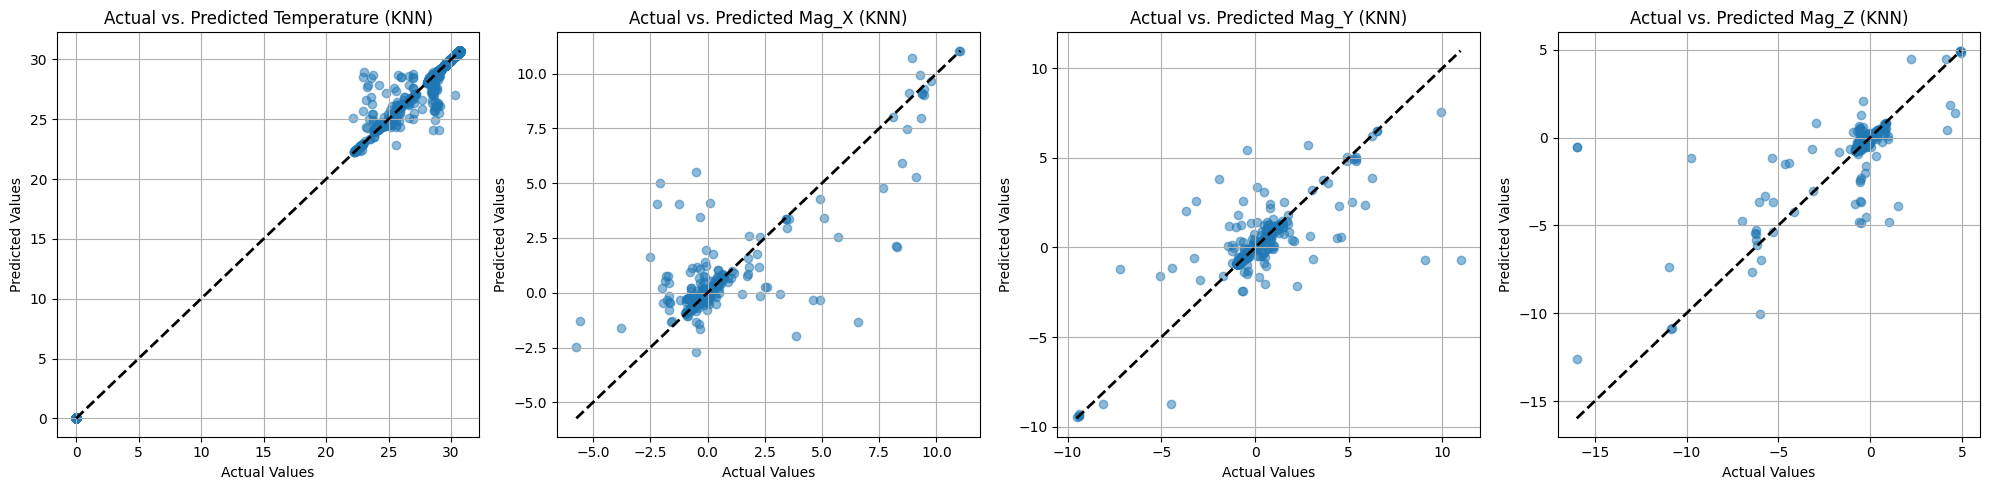

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
targets = ['Temperature', 'Mag_X', 'Mag_Y', 'Mag_Z']

for i, target in enumerate(targets):
    axes[i].scatter(y_test[target], y_pred_knn[:, i], alpha=0.5)
    axes[i].plot([y_test[target].min(), y_test[target].max()], [y_test[target].min(), y_test[target].max()], 'k--', lw=2)
    axes[i].set_title(f'Actual vs. Predicted {target} (KNN)')
    axes[i].set_xlabel('Actual Values')
    axes[i].set_ylabel('Predicted Values')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [20]:
# Create a DataFrame for actual and predicted values for KNN
temperature_magnetometer_results_knn = pd.DataFrame({
    'Actual_Temperature': y_test['Temperature'],
    'Predicted_Temperature_KNN': y_pred_knn[:, 0].round(2),
    'Actual_Mag_X': y_test['Mag_X'],
    'Predicted_Mag_X_KNN': y_pred_knn[:, 1].round(6),
    'Actual_Mag_Y': y_test['Mag_Y'],
    'Predicted_Mag_Y_KNN': y_pred_knn[:, 2].round(6),
    'Actual_Mag_Z': y_test['Mag_Z'],
    'Predicted_Mag_Z_KNN': y_pred_knn[:, 3].round(6)
})



In [21]:
non_zero_rows = temperature_magnetometer_results_knn[
    (temperature_magnetometer_results != 0).any(axis=1)
]

non_zero_rows=non_zero_rows.reset_index(drop=True)
non_zero_rows

,Actual_Temperature,Predicted_Temperature_KNN,Actual_Mag_X,Predicted_Mag_X_KNN,Actual_Mag_Y,Predicted_Mag_Y_KNN,Actual_Mag_Z,Predicted_Mag_Z_KNN
0,28.65,25.77,-0.125710,0.730252,-0.680445,-2.440921,-0.568368,0.544899
1,29.18,29.18,0.383101,0.382790,-0.603166,-0.601076,-0.527010,-0.526789
2,30.42,30.41,-0.704707,-0.705177,0.042619,0.041037,-0.489074,-0.490499
3,29.21,29.21,0.398763,0.399454,-0.617861,-0.618463,-0.544572,-0.544071
4,28.64,28.64,-0.072370,-0.072444,-0.723065,-0.723441,-0.532325,-0.534233
...,...,...,...,...,...,...,...,...
7265,30.72,30.70,-0.707646,-0.707567,0.037128,0.038211,-0.489663,-0.488448
7266,30.36,30.36,-0.690873,-0.695003,0.049142,0.046051,-0.487878,-0.489352
7267,28.59,28.59,-0.080025,-0.079519,-0.719799,-0.719887,-0.515826,-0.516623
7268,30.55,30.56,-0.714129,-0.701349,0.038570,0.041615,-0.487198,-0.487454


In [22]:
non_zero_rows.to_csv("temperature_magnetometer_results_knn.csv", index=False)

In [23]:
import joblib
joblib.dump(knn_model, 'k_neighbors_regressor_model.joblib')
print("KNN model save as 'k_neighbors_regressor_model.joblib'")

KNN model save as 'k_neighbors_regressor_model.joblib'
